# *Google Play Store dataset*

**lets gooooooooooooooooooooooo*

In [1]:
# import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)


In [2]:
#fetch the dataset
df = pd.read_excel("googleplaystore.xlsx")
df.head()


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite â€“ FREE Live Cool Themes, Hid...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


## Understand the basics related to dataset

In [3]:
# quick first look
df.head(10)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite â€“ FREE Live Cool Themes, Hid...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
5,Paper flowers instructions,ART_AND_DESIGN,4.4,167,5.6M,"50,000+",Free,0,Everyone,Art & Design,"March 26, 2017",1,2.3 and up
6,Smoke Effect Photo Maker - Smoke Editor,ART_AND_DESIGN,3.8,178,19M,"50,000+",Free,0,Everyone,Art & Design,"April 26, 2018",1.1,4.0.3 and up
7,Infinite Painter,ART_AND_DESIGN,4.1,36815,29M,"1,000,000+",Free,0,Everyone,Art & Design,"June 14, 2018",6.1.61.1,4.2 and up
8,Garden Coloring Book,ART_AND_DESIGN,4.4,13791,33M,"1,000,000+",Free,0,Everyone,Art & Design,"September 20, 2017",2.9.2,3.0 and up
9,Kids Paint Free - Drawing Fun,ART_AND_DESIGN,4.7,121,3.1M,"10,000+",Free,0,Everyone,Art & Design;Creativity,"July 3, 2018",2.8,4.0.3 and up


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  str    
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), object(6), str(6)
memory usage: 1.1+ MB


### **What is the shape of the dataset?*

In [5]:
print("Shape of the dataset (rows, columns):", df.shape)


Shape of the dataset (rows, columns): (10841, 13)


What are the data types of all columns? and Find out the name of all the columns

In [6]:
print("Column names:\n", list(df.columns))
print()
print("Data types of each column:")
print(df.dtypes)


Column names:
 ['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']

Data types of each column:
App                   str
Category           object
Rating            float64
Reviews            object
Size                  str
Installs           object
Type               object
Price              object
Content Rating        str
Genres                str
Last Updated          str
Current Ver        object
Android Ver           str
dtype: object


Which columns contain missing values?

In [7]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values and their counts:")
print(missing)


Columns with missing values and their counts:
Rating            1474
Current Ver          8
Android Ver          3
App                  1
Content Rating       1
Type                 1
dtype: int64


What percentage of values are missing in each column?

In [8]:
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
print("Percentage of missing values per column:")
print(missing_pct.round(2))


Percentage of missing values per column:
Rating            13.60
Current Ver        0.07
Android Ver        0.03
App                0.01
Type               0.01
Content Rating     0.01
dtype: float64


Find out the numerical  columns and categorical columns separately

In [9]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)


Numerical columns: ['Rating']
Categorical columns: ['App', 'Category', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']


/tmp/ipykernel_642/1964996486.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()


How many duplicate rows exist?

In [10]:
dup_count = df.duplicated().sum()
print(f"Number of fully duplicate rows: {dup_count}")


Number of fully duplicate rows: 483


Which apps appear more than once?

In [11]:
app_counts = df["App"].value_counts()
repeated_apps = app_counts[app_counts > 1]
print(f"Number of app names appearing more than once: {repeated_apps.shape[0]}")
repeated_apps.head(15)


Number of app names appearing more than once: 798


App
ROBLOX                                               9
CBS Sports App - Scores, News, Stats & Watch Live    8
Duolingo: Learn Languages Free                       7
Candy Crush Saga                                     7
8 Ball Pool                                          7
ESPN                                                 7
Nick                                                 6
Subway Surfers                                       6
Bubble Shooter                                       6
slither.io                                           6
Temple Run 2                                         6
Helix Jump                                           6
Zombie Catchers                                      6
Sniper 3D Gun Shooter: Free Shooting Games - FPS     6
Bowmasters                                           6
Name: count, dtype: int64

Are there apps with invalid ratings (>5 or <1)?

In [12]:
invalid_ratings = df[(df["Rating"] > 5) | (df["Rating"] < 1)]
print("Rows with an invalid Rating (>5 or <1):")
print(invalid_ratings[["App", "Category", "Rating", "Reviews", "Size", "Installs", "Type", "Price"]])

# This is App at index 10472: its Category shows "1.9" and Rating shows "19" -- a classic
# scraping error where one field (Category) was dropped, shifting every later value left by
# one column. Reviews/Size/Installs/Type/Price/Content Rating/Genres/Last Updated are all
# corrupted for this single row, so we drop it rather than try to "fix" shifted values.
df = df.drop(index=10472).reset_index(drop=True)
print("\nShape after removing the corrupted row:", df.shape)


Rows with an invalid Rating (>5 or <1):
                                           App Category  Rating Reviews    Size Installs Type     Price
10472  Life Made WI-Fi Touchscreen Photo Frame      1.9    19.0    3.0M  1,000+     Free    0  Everyone

Shape after removing the corrupted row: (10840, 13)


Are there categories with only a few observations?

In [13]:
category_counts = df["Category"].value_counts()
print("Number of apps per category (smallest to largest):")
print(category_counts.sort_values().head(10))
print()
print("Largest categories for comparison:")
print(category_counts.sort_values(ascending=False).head(5))


Number of apps per category (smallest to largest):
Category
BEAUTY                 53
COMICS                 60
PARENTING              60
EVENTS                 64
ART_AND_DESIGN         65
WEATHER                82
LIBRARIES_AND_DEMO     85
AUTO_AND_VEHICLES      85
HOUSE_AND_HOME         88
FOOD_AND_DRINK        127
Name: count, dtype: int64

Largest categories for comparison:
Category
FAMILY      1972
GAME        1144
TOOLS        843
MEDICAL      463
BUSINESS     460
Name: count, dtype: int64


Convert Reviews, Installs, Size, and Price into numeric form.

In [14]:
# Convert Reviews, Installs, Size, and Price into numeric form

# Reviews: already numeric-looking strings -> int
df["Reviews"] = pd.to_numeric(df["Reviews"], errors="coerce").astype("Int64")

# Installs: strip "," and "+" then convert to int
df["Installs"] = (
    df["Installs"].astype(str).str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
)
df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce").astype("Int64")

# Size: convert "19M" -> 19.0 (MB), "500k" -> 0.488 (MB), "Varies with device" -> NaN
def parse_size(x):
    x = str(x).strip()
    if x == "Varies with device" or x.lower() == "nan":
        return np.nan
    if x.endswith("M"):
        return float(x[:-1])
    if x.endswith("k"):
        return float(x[:-1]) / 1024
    try:
        return float(x)
    except ValueError:
        return np.nan

df["Size_MB"] = df["Size"].apply(parse_size)

# Price: strip "$" then convert to float
df["Price"] = (
    df["Price"].astype(str).str.replace("$", "", regex=False)
)
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

print(df[["Reviews", "Installs", "Size_MB", "Price"]].dtypes)
df[["App", "Reviews", "Installs", "Size", "Size_MB", "Price"]].head()


Reviews       Int64
Installs      Int64
Size_MB     float64
Price       float64
dtype: object


,App,Reviews,Installs,Size,Size_MB,Price
0,Photo Editor & Candy Camera & Grid & ScrapBook,159,10000,19M,19.0,0.0
1,Coloring book moana,967,500000,14M,14.0,0.0
2,"U Launcher Lite â€“ FREE Live Cool Themes, Hid...",87510,5000000,8.7M,8.7,0.0
3,Sketch - Draw & Paint,215644,50000000,25M,25.0,0.0
4,Pixel Draw - Number Art Coloring Book,967,100000,2.8M,2.8,0.0


How many apps have zero reviews?

In [15]:
zero_reviews = (df["Reviews"] == 0).sum()
pct_zero = zero_reviews / len(df) * 100
print(f"Apps with zero reviews: {zero_reviews} ({pct_zero:.2f}% of all apps)")


Apps with zero reviews: 596 (5.50% of all apps)


How are ratings distributed? and Explain within markdown what u understood from this distribution

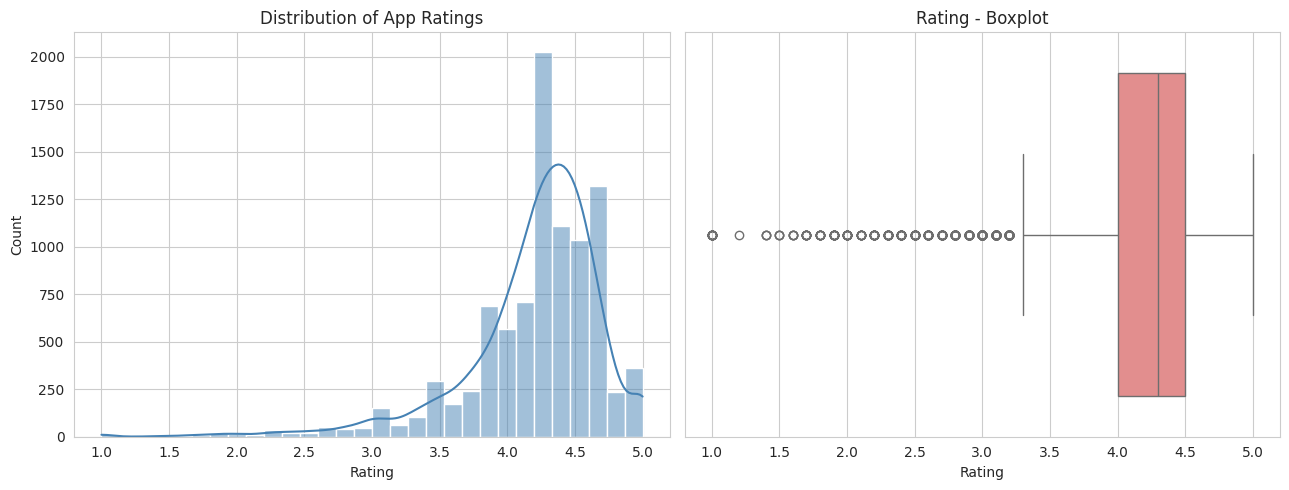

count    9366.000000
mean        4.191757
std         0.515219
min         1.000000
25%         4.000000
50%         4.300000
75%         4.500000
max         5.000000
Name: Rating, dtype: float64

Skewness: -1.85
Mode: [4.4]


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(df["Rating"].dropna(), bins=30, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of App Ratings")
axes[0].set_xlabel("Rating")

sns.boxplot(x=df["Rating"].dropna(), ax=axes[1], color="lightcoral")
axes[1].set_title("Rating - Boxplot")
plt.tight_layout()
plt.show()

print(df["Rating"].describe())
print("\nSkewness:", round(df["Rating"].skew(), 3))
print("Mode:", df["Rating"].mode().tolist())


**What this tells us:**

The Rating distribution is strongly **left-skewed (negatively skewed)** — most apps cluster tightly
between roughly **4.0 and 4.5**, with a long thin tail stretching down toward 1.0. The mean
(~4.19) sits below the mode, which is the signature of left skew. Very few apps have ratings
below 3.0.

This pattern is typical of app-store rating data and reflects **survivorship/selection bias**:
apps that get terrible ratings tend to get pulled, abandoned, or simply never accumulate enough
reviews to show a stable score, while users who bother to rate an app at all are disproportionately
satisfied users. So the distribution is not really "ratings of all apps" so much as "ratings of
apps that survived long enough to be rated."


In [17]:
print("Percentiles:")
print(df["Rating"].quantile([0.1, 0.25, 0.5, 0.75, 0.9, 0.95]).round(2))


Percentiles:
0.10    3.6
0.25    4.0
0.50    4.3
0.75    4.5
0.90    4.7
0.95    4.8
Name: Rating, dtype: float64


Are ratings normally distributed?

In [18]:
from scipy.stats import shapiro, normaltest

sample = df["Rating"].dropna()
stat_sw, p_sw = shapiro(sample.sample(min(5000, len(sample)), random_state=42))
stat_k2, p_k2 = normaltest(sample)

print(f"Shapiro-Wilk test:      statistic={stat_sw:.4f}, p-value={p_sw:.6f}")
print(f"D'Agostino-Pearson test: statistic={stat_k2:.4f}, p-value={p_k2:.6f}")
print(f"\nSkewness: {sample.skew():.3f}   Kurtosis: {sample.kurtosis():.3f}")


Shapiro-Wilk test:      statistic=0.8664, p-value=0.000000
D'Agostino-Pearson test: statistic=3678.6157, p-value=0.000000

Skewness: -1.850   Kurtosis: 5.787


**Explanation:** Both normality tests return a p-value far below 0.05, so we **reject the null
hypothesis of normality** — Ratings are **not normally distributed**. This matches the histogram:
a roughly bell-shaped normal curve would be symmetric around the mean, but our distribution is
clearly skewed left with a sharp peak around 4.0–4.5 and a long tail toward low ratings, plus the
skewness/kurtosis values being far from 0/3. With a sample this large, even tiny deviations from
normality produce a significant test, but the visual evidence (histogram + boxplot above) confirms
this isn't just a large-sample artifact — the shape genuinely departs from a normal curve.


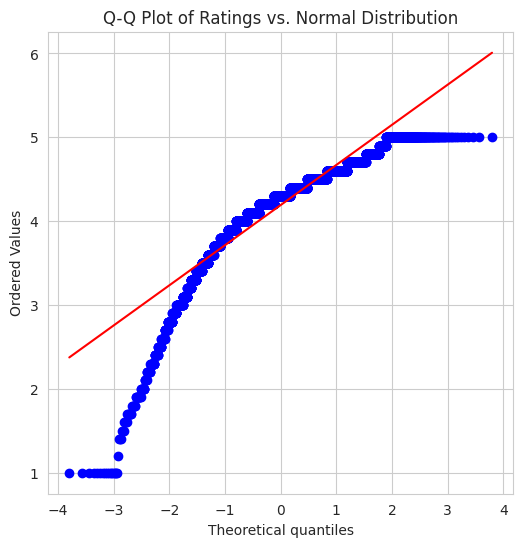

In [19]:
import scipy.stats as ss
fig, ax = plt.subplots(figsize=(6, 6))
ss.probplot(sample, dist="norm", plot=ax)
ax.set_title("Q-Q Plot of Ratings vs. Normal Distribution")
plt.show()


Which rating range contains most apps?

Rating
1-2        68
2-3       302
3-4      2196
4-4.5    4883
4.5-5    1917
Name: count, dtype: int64

Most apps fall in the '4-4.5' range, with 4883 apps.


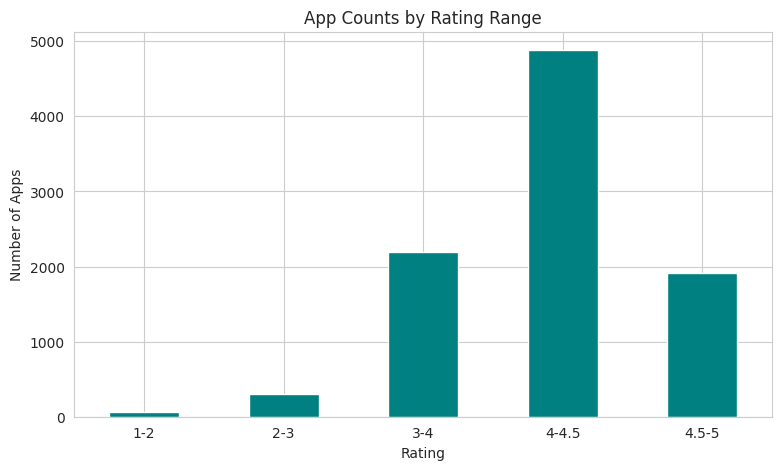

In [20]:
bins = [1, 2, 3, 4, 4.5, 5]
labels = ["1-2", "2-3", "3-4", "4-4.5", "4.5-5"]
rating_bins = pd.cut(df["Rating"], bins=bins, labels=labels, include_lowest=True)
counts = rating_bins.value_counts().sort_index()
print(counts)
print(f"\nMost apps fall in the '{counts.idxmax()}' range, with {counts.max()} apps.")

counts.plot(kind="bar", color="teal")
plt.title("App Counts by Rating Range")
plt.ylabel("Number of Apps")
plt.xticks(rotation=0)
plt.show()


What is the average app size?

In [21]:
avg_size = df["Size_MB"].mean()
print(f"Average app size: {avg_size:.2f} MB")
print(f"Median app size: {df['Size_MB'].median():.2f} MB")
print(f"Apps with size unknown ('Varies with device'): {df['Size_MB'].isna().sum()}")


Average app size: 21.52 MB
Median app size: 13.00 MB
Apps with size unknown ('Varies with device'): 1695


How are app sizes distributed?

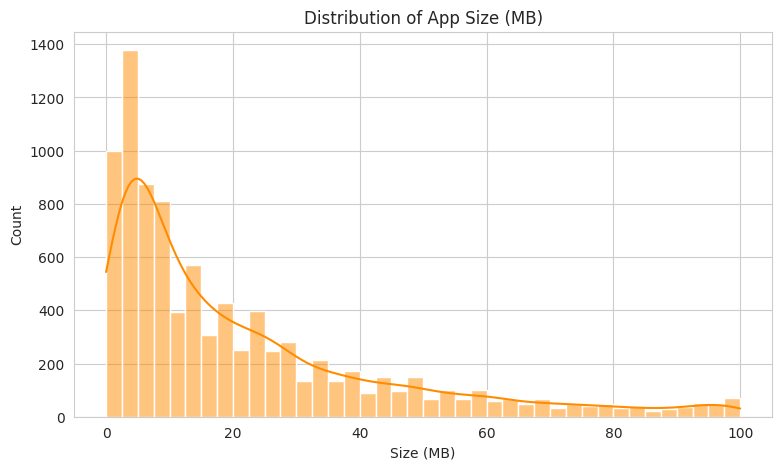

count    9145.000000
mean       21.516165
std        22.589084
min         0.008301
25%         4.900000
50%        13.000000
75%        30.000000
max       100.000000
Name: Size_MB, dtype: float64
Skewness: 1.557


In [22]:
plt.figure(figsize=(9, 5))
sns.histplot(df["Size_MB"].dropna(), bins=40, kde=True, color="darkorange")
plt.title("Distribution of App Size (MB)")
plt.xlabel("Size (MB)")
plt.show()

print(df["Size_MB"].describe())
print("Skewness:", round(df["Size_MB"].skew(), 3))


**Explanation:** App size is **right-skewed** — most apps are small (well under ~30 MB), but a
long tail of large apps (games, media apps) stretches out past 90-100 MB, pulling the mean
(~21 MB) above the median. There's also a visible concentration of apps near common size
"checkpoints" (e.g., apps just under the old Play Store auto-download-over-WiFi limits),
which shows up as small bumps rather than a perfectly smooth curve.


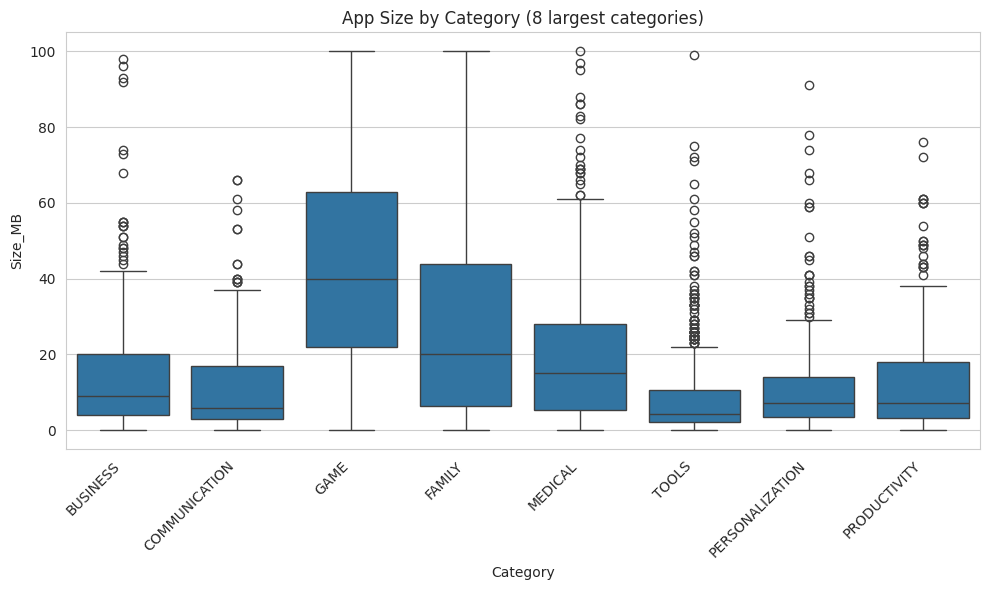

In [23]:
top_categories_by_count = df["Category"].value_counts().head(8).index
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[df["Category"].isin(top_categories_by_count)], x="Category", y="Size_MB")
plt.title("App Size by Category (8 largest categories)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


Which content rating category is most common?

In [24]:
content_counts = df["Content Rating"].value_counts()
print(content_counts)
print(f"\nMost common content rating: '{content_counts.idxmax()}' ({content_counts.max()} apps, "
      f"{content_counts.max()/len(df)*100:.1f}% of all apps)")


Content Rating
Everyone           8714
Teen               1208
Mature 17+          499
Everyone 10+        414
Adults only 18+       3
Unrated               2
Name: count, dtype: int64

Most common content rating: 'Everyone' (8714 apps, 80.4% of all apps)


What percentage of apps are free?

In [25]:
free_pct = (df["Type"] == "Free").mean() * 100
print(f"Percentage of apps that are Free: {free_pct:.2f}%")


Percentage of apps that are Free: 92.61%


What percentage are paid?

In [26]:
paid_pct = (df["Type"] == "Paid").mean() * 100
print(f"Percentage of apps that are Paid: {paid_pct:.2f}%")


Percentage of apps that are Paid: 7.38%


What is the maximum price of an app?

In [27]:
max_price = df["Price"].max()
print(f"Maximum app price: ${max_price:.2f}")


Maximum app price: $400.00


Which category contains the largest number of apps?

In [28]:
largest_cat = df["Category"].value_counts().idxmax()
print(f"Category with the most apps: {largest_cat} ({df['Category'].value_counts().max()} apps)")


Category with the most apps: FAMILY (1972 apps)


Which category contains the fewest apps?

In [29]:
smallest_cat = df["Category"].value_counts().idxmin()
print(f"Category with the fewest apps: {smallest_cat} ({df['Category'].value_counts().min()} apps)")


Category with the fewest apps: BEAUTY (53 apps)


Which category has the highest average rating?

In [30]:
avg_rating_by_cat = df.groupby("Category")["Rating"].mean().sort_values(ascending=False)
print(f"Highest average rating: {avg_rating_by_cat.idxmax()} ({avg_rating_by_cat.max():.2f})")
avg_rating_by_cat.head(5)


Highest average rating: EVENTS (4.44)


Category
EVENTS                 4.435556
EDUCATION              4.389032
ART_AND_DESIGN         4.358065
BOOKS_AND_REFERENCE    4.346067
PERSONALIZATION        4.335987
Name: Rating, dtype: float64

Which category has the lowest average rating?

In [31]:
print(f"Lowest average rating: {avg_rating_by_cat.idxmin()} ({avg_rating_by_cat.min():.2f})")
avg_rating_by_cat.tail(5)


Lowest average rating: DATING (3.97)


Category
LIFESTYLE              4.094904
VIDEO_PLAYERS          4.063750
MAPS_AND_NAVIGATION    4.051613
TOOLS                  4.047411
DATING                 3.970769
Name: Rating, dtype: float64

Which category receives the highest total number of reviews?

In [32]:
reviews_by_cat = df.groupby("Category")["Reviews"].sum().sort_values(ascending=False)
print(f"Category with highest total reviews: {reviews_by_cat.idxmax()} ({reviews_by_cat.max():,})")
reviews_by_cat.head(5)


Category with highest total reviews: GAME (1,585,422,349)


Category
GAME             1585422349
COMMUNICATION     815462260
SOCIAL            621241422
FAMILY            410226330
TOOLS             273185044
Name: Reviews, dtype: Int64

Which category has the highest average installs?

In [33]:
installs_by_cat = df.groupby("Category")["Installs"].mean().sort_values(ascending=False)
print(f"Category with highest average installs: {installs_by_cat.idxmax()} ({installs_by_cat.max():,.0f})")
installs_by_cat.head(5)


Category with highest average installs: COMMUNICATION (84,359,887)


Category
COMMUNICATION    84359886.953488
SOCIAL           47694467.464407
VIDEO_PLAYERS    35554301.257143
PRODUCTIVITY     33434177.757075
GAME             30669601.761364
Name: Installs, dtype: Float64

Which category has the largest app sizes?

In [34]:
size_by_cat = df.groupby("Category")["Size_MB"].mean().sort_values(ascending=False)
print(f"Category with the largest average app size: {size_by_cat.idxmax()} ({size_by_cat.max():.1f} MB)")
size_by_cat.head(5)


Category with the largest average app size: GAME (44.4 MB)


Category
GAME                  44.370065
FAMILY                28.319023
TRAVEL_AND_LOCAL      24.654463
SPORTS                24.338822
HEALTH_AND_FITNESS    22.768851
Name: Size_MB, dtype: float64

Which category contains the most paid apps?

In [35]:
paid_by_cat = df[df["Type"] == "Paid"]["Category"].value_counts()
print(f"Category with most paid apps: {paid_by_cat.idxmax()} ({paid_by_cat.max()} paid apps)")
paid_by_cat.head(5)


Category with most paid apps: FAMILY (191 paid apps)


Category
FAMILY             191
MEDICAL            109
GAME                83
PERSONALIZATION     83
TOOLS               78
Name: count, dtype: int64

Which category contains the highest percentage of free apps?

In [36]:
free_pct_by_cat = df.groupby("Category")["Type"].apply(lambda s: (s == "Free").mean() * 100)
free_pct_by_cat = free_pct_by_cat.sort_values(ascending=False)
print(f"Category with highest % of free apps: {free_pct_by_cat.idxmax()} ({free_pct_by_cat.max():.1f}% free)")
free_pct_by_cat.head(5)


Category with highest % of free apps: BEAUTY (100.0% free)


Category
BEAUTY                100.000000
HOUSE_AND_HOME        100.000000
COMICS                100.000000
NEWS_AND_MAGAZINES     99.293286
SHOPPING               99.230769
Name: Type, dtype: float64

Are certain categories dominated by a single content rating?

In [37]:
dominance = df.groupby("Category")["Content Rating"].apply(lambda s: s.value_counts(normalize=True).iloc[0] * 100)
dominance = dominance.sort_values(ascending=False)
print("Categories most dominated by a single Content Rating (% share of top rating):")
print(dominance.head(10).round(1))


Categories most dominated by a single Content Rating (% share of top rating):
Category
LIBRARIES_AND_DEMO     100.0
TOOLS                   99.1
FINANCE                 98.6
HOUSE_AND_HOME          97.7
AUTO_AND_VEHICLES       97.6
PRODUCTIVITY            97.4
TRAVEL_AND_LOCAL        97.3
MAPS_AND_NAVIGATION     97.1
BUSINESS                96.7
PARENTING               96.7
Name: Content Rating, dtype: float64


What are the top 20 highest-rated apps?

In [38]:
top20 = (
    df.dropna(subset=["App"])
      .sort_values(["Rating", "Reviews"], ascending=[False, False])
      .drop_duplicates(subset="App")
      .head(20)
)
top20[["App", "Category", "Rating", "Reviews", "Installs"]]


,App,Category,Rating,Reviews,Installs
10357,RÃ­os de Fe,LIFESTYLE,5.0,141,1000
10301,"FD Calculator (EMI, SIP, RD & Loan Eligilibility)",FINANCE,5.0,104,1000
8058,OraciÃ³n CX,LIFESTYLE,5.0,103,5000
6823,Barisal University App-BU Face,FAMILY,5.0,100,1000
9496,Master E.K,FAMILY,5.0,90,1000
7506,CL REPL,TOOLS,5.0,47,1000
5230,AJ Cam,PHOTOGRAPHY,5.0,44,100
5196,AI Today : Artificial Intelligence News & AI 101,NEWS_AND_MAGAZINES,5.0,43,100
7842,CS & IT Interview Questions,FAMILY,5.0,43,1000
9517,Ek Vote,PRODUCTIVITY,5.0,43,500


Which category contributes most of the 5-star apps?

In [39]:
five_star = df[df["Rating"] == 5.0]
contrib = five_star["Category"].value_counts()
print(f"Total 5-star rated apps: {len(five_star)}")
print(f"Category contributing the most 5-star apps: {contrib.idxmax()} ({contrib.max()} apps)")
contrib.head(5)


Total 5-star rated apps: 274
Category contributing the most 5-star apps: FAMILY (67 apps)


Category
FAMILY       67
LIFESTYLE    29
MEDICAL      28
BUSINESS     18
TOOLS        17
Name: count, dtype: int64

Do apps with more reviews receive higher ratings?

Correlation between Reviews and Rating: 0.068


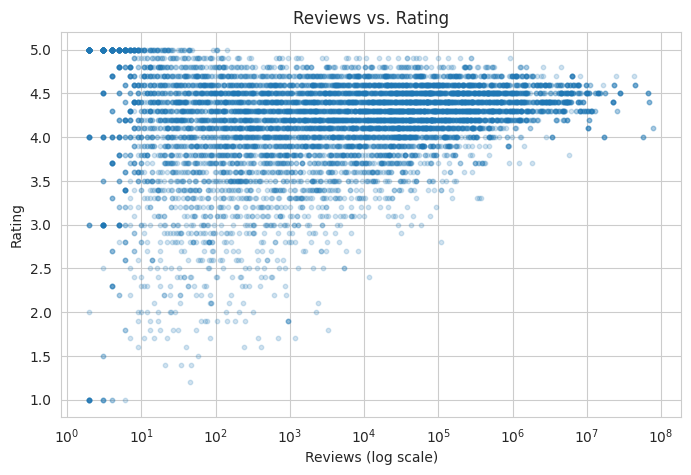

There is a weak positive relationship -- more reviews does not strongly predict a higher rating.


In [40]:
corr_reviews_rating = df["Reviews"].corr(df["Rating"])
print(f"Correlation between Reviews and Rating: {corr_reviews_rating:.3f}")

plt.figure(figsize=(8, 5))
plt.scatter(df["Reviews"] + 1, df["Rating"], alpha=0.2, s=10)
plt.xscale("log")
plt.xlabel("Reviews (log scale)")
plt.ylabel("Rating")
plt.title("Reviews vs. Rating")
plt.show()

verdict = "a weak positive" if 0 < corr_reviews_rating < 0.3 else ("a weak/negligible" if abs(corr_reviews_rating) <= 0.1 else "a notable")
print(f"There is {verdict} relationship -- more reviews does not strongly predict a higher rating.")


Do highly installed apps have better ratings?

Correlation between Installs and Rating: 0.051


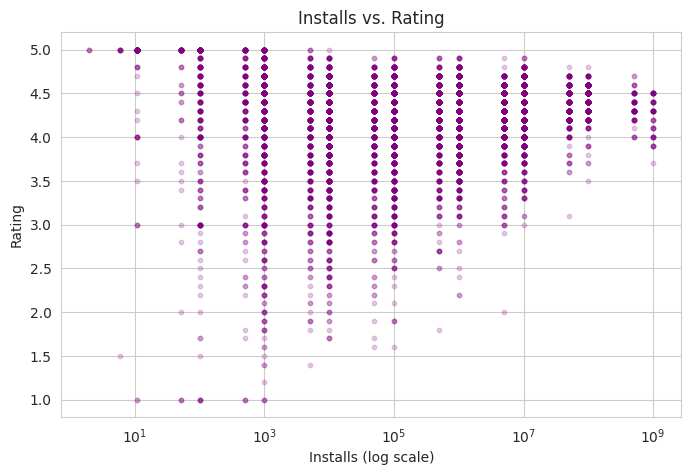

In [41]:
corr_installs_rating = df["Installs"].corr(df["Rating"])
print(f"Correlation between Installs and Rating: {corr_installs_rating:.3f}")

plt.figure(figsize=(8, 5))
plt.scatter(df["Installs"] + 1, df["Rating"], alpha=0.2, s=10, color="purple")
plt.xscale("log")
plt.xlabel("Installs (log scale)")
plt.ylabel("Rating")
plt.title("Installs vs. Rating")
plt.show()


Which category has the greatest variation in ratings?

In [42]:
rating_std_by_cat = df.groupby("Category")["Rating"].std().sort_values(ascending=False)
print(f"Category with the greatest variation (std dev) in ratings: {rating_std_by_cat.idxmax()} "
      f"(std = {rating_std_by_cat.max():.3f})")
rating_std_by_cat.head(5)


Category with the greatest variation (std dev) in ratings: LIFESTYLE (std = 0.694)


Category
LIFESTYLE    0.693907
MEDICAL      0.663581
FINANCE      0.642108
DATING       0.630510
BUSINESS     0.624422
Name: Rating, dtype: float64

Are ratings different between free and paid apps?

In [43]:
free_ratings = df[df["Type"] == "Free"]["Rating"].dropna()
paid_ratings = df[df["Type"] == "Paid"]["Rating"].dropna()

t_stat, p_val = stats.ttest_ind(free_ratings, paid_ratings, equal_var=False)
print(f"Mean rating - Free: {free_ratings.mean():.3f}   Paid: {paid_ratings.mean():.3f}")
print(f"Welch's t-test: t={t_stat:.3f}, p={p_val:.5f}")
print("=> Statistically significant difference" if p_val < 0.05 else "=> No statistically significant difference")


Mean rating - Free: 4.186   Paid: 4.267
Welch's t-test: t=-3.620, p=0.00031
=> Statistically significant difference


Which apps have the highest installs?

In [44]:
max_installs = df["Installs"].max()
top_installed = df[df["Installs"] == max_installs][["App", "Category", "Installs", "Rating"]].drop_duplicates("App")
print(f"Apps tied at the highest install bucket ({max_installs:,}+):")
top_installed.head(15)


Apps tied at the highest install bucket (1,000,000,000+):


,App,Category,Installs,Rating
152,Google Play Books,BOOKS_AND_REFERENCE,1000000000,3.9
335,Messenger â€“ Text and Video Chat for Free,COMMUNICATION,1000000000,4.0
336,WhatsApp Messenger,COMMUNICATION,1000000000,4.4
338,Google Chrome: Fast & Secure,COMMUNICATION,1000000000,4.3
340,Gmail,COMMUNICATION,1000000000,4.3
341,Hangouts,COMMUNICATION,1000000000,4.0
391,Skype - free IM & video calls,COMMUNICATION,1000000000,4.1
865,Google Play Games,ENTERTAINMENT,1000000000,4.3
1654,Subway Surfers,GAME,1000000000,4.5
2544,Facebook,SOCIAL,1000000000,4.1


Do larger apps tend to have higher ratings?

In [45]:
corr_size_rating = df["Size_MB"].corr(df["Rating"])
print(f"Correlation between Size_MB and Rating: {corr_size_rating:.3f}")
print("=> Essentially no linear relationship; bigger apps are not meaningfully better rated.")


Correlation between Size_MB and Rating: 0.084
=> Essentially no linear relationship; bigger apps are not meaningfully better rated.


Are older apps rated differently than recently updated apps?

In [46]:
# Parse Last Updated into a usable date / year (first time we need it)
df["Last_Updated_dt"] = pd.to_datetime(df["Last Updated"], errors="coerce")
df["Update_Year"] = df["Last_Updated_dt"].dt.year

recent = df[df["Update_Year"] >= 2018]["Rating"].dropna()
older = df[df["Update_Year"] < 2018]["Rating"].dropna()

t_stat, p_val = stats.ttest_ind(recent, older, equal_var=False)
print(f"Mean rating - Updated in 2018: {recent.mean():.3f}   Updated before 2018: {older.mean():.3f}")
print(f"Welch's t-test: t={t_stat:.3f}, p={p_val:.5f}")
print("=> Statistically significant difference" if p_val < 0.05 else "=> No statistically significant difference")


Mean rating - Updated in 2018: 4.245   Updated before 2018: 4.072
Welch's t-test: t=13.937, p=0.00000
=> Statistically significant difference


Which category has the most consistent ratings?

In [47]:
min_count_cats = df["Category"].value_counts()
eligible = min_count_cats[min_count_cats >= 30].index
consistent = rating_std_by_cat[rating_std_by_cat.index.isin(eligible)].sort_values()
print("Most consistent ratings (lowest std dev, categories with >=30 apps):")
print(consistent.head(5).round(3))


Most consistent ratings (lowest std dev, categories with >=30 apps):
Category
EDUCATION          0.252
ENTERTAINMENT      0.303
WEATHER            0.331
PERSONALIZATION    0.353
ART_AND_DESIGN     0.358
Name: Rating, dtype: float64


Which category contributes the highest total installs?

In [48]:
installs_total_by_cat = df.groupby("Category")["Installs"].sum().sort_values(ascending=False)
print(f"Category with the highest total installs: {installs_total_by_cat.idxmax()} "
      f"({installs_total_by_cat.max():,})")
installs_total_by_cat.head(10)


Category with the highest total installs: GAME (35,086,024,415)


Category
GAME                  35086024415
COMMUNICATION         32647276251
PRODUCTIVITY          14176091369
SOCIAL                14069867902
TOOLS                 11452771915
FAMILY                10258263505
PHOTOGRAPHY           10088247655
NEWS_AND_MAGAZINES     7496317760
TRAVEL_AND_LOCAL       6868887146
VIDEO_PLAYERS          6222002720
Name: Installs, dtype: Int64

What is the relationship between reviews and ratings?

In [49]:
df["Review_Quartile"] = pd.qcut(df["Reviews"], 4, labels=["Q1 (fewest)", "Q2", "Q3", "Q4 (most)"], duplicates="drop")
print(df.groupby("Review_Quartile")["Rating"].mean().round(3))
print(f"\nOverall Pearson correlation: {df['Reviews'].corr(df['Rating']):.3f}")
print(f"Overall Spearman correlation: {df['Reviews'].corr(df['Rating'], method='spearman'):.3f}")


Review_Quartile
Q1 (fewest)    4.140
Q2             4.037
Q3             4.198
Q4 (most)      4.360
Name: Rating, dtype: float64

Overall Pearson correlation: 0.068
Overall Spearman correlation: 0.156


Do paid apps receive fewer installs than free apps?

In [50]:
free_installs = df[df["Type"] == "Free"]["Installs"]
paid_installs = df[df["Type"] == "Paid"]["Installs"]

print(f"Median installs - Free: {free_installs.median():,}   Paid: {paid_installs.median():,}")
print(f"Mean installs   - Free: {free_installs.mean():,.0f}   Paid: {paid_installs.mean():,.0f}")

u_stat, p_val = stats.mannwhitneyu(free_installs.dropna(), paid_installs.dropna(), alternative="greater")
print(f"\nMann-Whitney U test (Free > Paid): p={p_val:.2e}")
print("=> Free apps get significantly more installs than paid apps." if p_val < 0.05 else "=> No significant difference.")


Median installs - Free: 100,000.0   Paid: 1,000.0
Mean installs   - Free: 16,690,953   Paid: 91,195

Mann-Whitney U test (Free > Paid): p=9.10e-143
=> Free apps get significantly more installs than paid apps.


What percentage of apps have fewer than 10,000 installs?

In [51]:
pct_low_installs = (df["Installs"] < 10000).mean() * 100
print(f"Percentage of apps with fewer than 10,000 installs: {pct_low_installs:.2f}%")


Percentage of apps with fewer than 10,000 installs: 29.41%


Are highly-rated apps downloaded more frequently?

In [52]:
avg_installs_by_rating_bin = df.groupby(rating_bins)["Installs"].mean()
print("Average installs by rating range:")
print(avg_installs_by_rating_bin.round(0))


Average installs by rating range:
Rating
1-2         91127.0
2-3        185349.0
3-4       9089195.0
4-4.5    26756409.0
4.5-5     8843959.0
Name: Installs, dtype: Float64


Which content-rating group has the highest installs?

In [53]:
installs_by_content = df.groupby("Content Rating")["Installs"].agg(["mean", "sum"]).sort_values("sum", ascending=False)
print(installs_by_content)
print(f"\nHighest total installs: {installs_by_content['sum'].idxmax()}")
print(f"Highest average installs: {installs_by_content['mean'].idxmax()}")


                            mean           sum
Content Rating                                
Everyone         13100374.067133  114156659621
Teen             28738700.656457   34716350393
Everyone 10+     31965898.055556   13233881795
Mature 17+        11071124.60521    5524491178
Adults only 18+    666666.666667       2000000
Unrated                  25250.0         50500

Highest total installs: Everyone
Highest average installs: Everyone 10+


Which category contains the greatest number of apps with over 1 million installs?

In [54]:
million_plus = df[df["Installs"] >= 1_000_000]
cat_million = million_plus["Category"].value_counts()
print(f"Category with the most apps over 1M installs: {cat_million.idxmax()} ({cat_million.max()} apps)")
cat_million.head(5)


Category with the most apps over 1M installs: GAME (737 apps)


Category
GAME             737
FAMILY           651
TOOLS            289
PHOTOGRAPHY      226
COMMUNICATION    212
Name: count, dtype: int64

Are installs concentrated among a few apps?

In [55]:
installs_sorted = df["Installs"].sort_values(ascending=False)
total_installs = installs_sorted.sum()
top1pct_n = max(1, int(len(installs_sorted) * 0.01))
top10pct_n = max(1, int(len(installs_sorted) * 0.10))

share_top1 = installs_sorted.head(top1pct_n).sum() / total_installs * 100
share_top10 = installs_sorted.head(top10pct_n).sum() / total_installs * 100

print(f"Top 1% of apps ({top1pct_n} apps) account for {share_top1:.1f}% of total installs")
print(f"Top 10% of apps ({top10pct_n} apps) account for {share_top10:.1f}% of total installs")
print("=> Installs are heavily concentrated among a small number of blockbuster apps.")


Top 1% of apps (108 apps) account for 49.5% of total installs
Top 10% of apps (1084 apps) account for 90.6% of total installs
=> Installs are heavily concentrated among a small number of blockbuster apps.


What is the average price of paid apps?

In [56]:
avg_paid_price = df[df["Type"] == "Paid"]["Price"].mean()
print(f"Average price of paid apps: ${avg_paid_price:.2f}")


Average price of paid apps: $13.92


Which category has the most expensive apps?

In [57]:
price_by_cat = df[df["Type"] == "Paid"].groupby("Category")["Price"].mean().sort_values(ascending=False)
print(f"Category with the most expensive apps (avg price among paid): {price_by_cat.idxmax()} (${price_by_cat.max():.2f})")
price_by_cat.head(5).round(2)


Category with the most expensive apps (avg price among paid): FINANCE ($170.64)


Category
FINANCE      170.64
LIFESTYLE    124.26
EVENTS       109.99
BUSINESS      13.23
MEDICAL       13.21
Name: Price, dtype: float64

What is the distribution of installs?

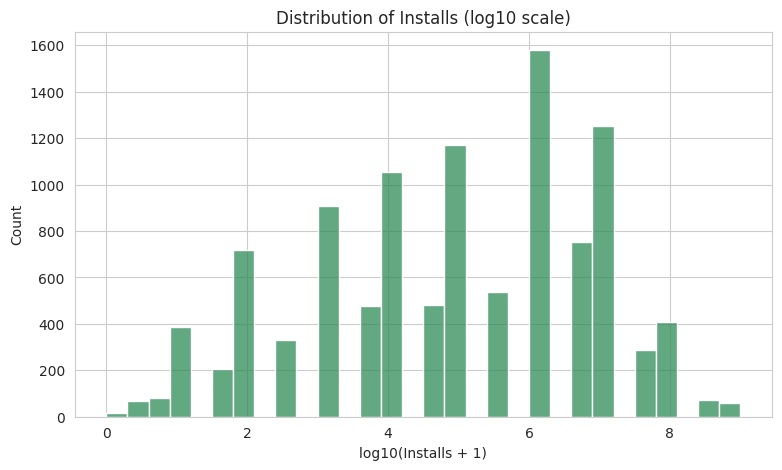

count           10,840
mean        15,464,339
std         85,029,361
min                  0
25%              1,000
50%            100,000
75%          5,000,000
max      1,000,000,000
Name: Installs, dtype: str

In [58]:
plt.figure(figsize=(9, 5))
sns.histplot(np.log10(df["Installs"] + 1), bins=30, color="seagreen")
plt.title("Distribution of Installs (log10 scale)")
plt.xlabel("log10(Installs + 1)")
plt.show()

print(df["Installs"].describe().apply(lambda x: f"{x:,.0f}"))


Which genre contains the largest number of apps?

In [59]:
genre_exploded = df["Genres"].dropna().str.split(";").explode().str.strip()
genre_counts = genre_exploded.value_counts()
print(f"Genre with the largest number of apps: {genre_counts.idxmax()} ({genre_counts.max()} apps)")
genre_counts.head(10)


Genre with the largest number of apps: Tools (843 apps)


Genres
Tools              843
Education          761
Entertainment      667
Medical            463
Business           460
Productivity       424
Sports             402
Personalization    392
Communication      388
Lifestyle          383
Name: count, dtype: int64

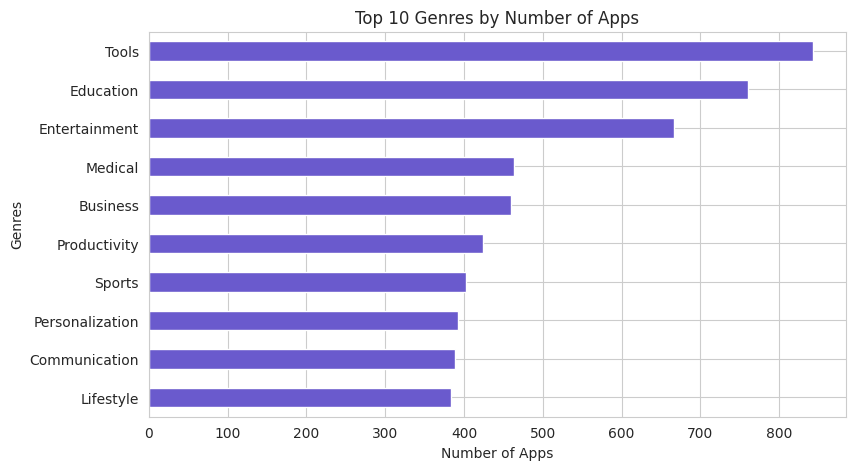

In [60]:
genre_counts.head(10).plot(kind="barh", color="slateblue")
plt.gca().invert_yaxis()
plt.title("Top 10 Genres by Number of Apps")
plt.xlabel("Number of Apps")
plt.show()


Does higher price imply higher ratings?

Correlation between Price and Rating (paid apps only): -0.113


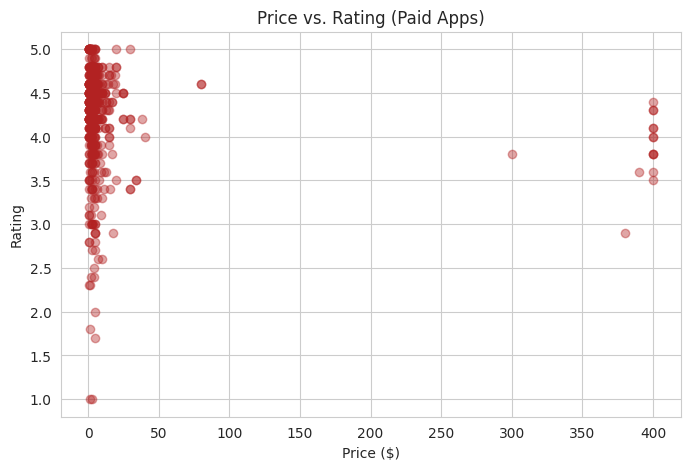

=> Correlation is close to zero -- paying more does not buy a better rating.


In [61]:
paid_apps = df[df["Type"] == "Paid"]
corr_price_rating = paid_apps["Price"].corr(paid_apps["Rating"])
print(f"Correlation between Price and Rating (paid apps only): {corr_price_rating:.3f}")

plt.figure(figsize=(8, 5))
plt.scatter(paid_apps["Price"], paid_apps["Rating"], alpha=0.4, color="firebrick")
plt.xlabel("Price ($)")
plt.ylabel("Rating")
plt.title("Price vs. Rating (Paid Apps)")
plt.show()
print("=> Correlation is close to zero -- paying more does not buy a better rating.")


Which app is the most expensive?

In [62]:
most_expensive = df.sort_values("Price", ascending=False).drop_duplicates("App").head(5)
most_expensive[["App", "Category", "Price", "Rating", "Installs"]]


,App,Category,Price,Rating,Installs
4367,I'm Rich - Trump Edition,LIFESTYLE,400.00,3.6,10000
9934,I'm Rich/Eu sou Rico/Ø£Ù†Ø§ ØºÙ†ÙŠ/æˆ‘å¾ˆæœ‰éŒ¢,LIFESTYLE,399.99,NaN,0
4197,most expensive app (H),FAMILY,399.99,4.3,100
5351,I am rich,LIFESTYLE,399.99,3.8,100000
5354,I am Rich Plus,FAMILY,399.99,4.0,10000


Which category generates the highest total revenue potential?

In [63]:
df["Revenue_Potential"] = df["Price"] * df["Installs"]
revenue_by_cat = df.groupby("Category")["Revenue_Potential"].sum().sort_values(ascending=False)
print(f"Category with the highest total revenue potential: {revenue_by_cat.idxmax()} "
      f"(${revenue_by_cat.max():,.0f})")
revenue_by_cat.head(10)


Category with the highest total revenue potential: FAMILY ($186,052,625)


Category
FAMILY             186052625.36
LIFESTYLE            57583939.4
GAME                40987636.85
FINANCE             25726678.98
PHOTOGRAPHY          20922767.7
MEDICAL             13574843.67
PERSONALIZATION     10276947.56
TOOLS                5464820.59
SPORTS               4706211.95
PRODUCTIVITY         4313374.95
Name: Revenue_Potential, dtype: Float64

Does price affect installs?

In [64]:
corr_price_installs_all = df["Price"].corr(df["Installs"])
corr_price_installs_paid = paid_apps["Price"].corr(paid_apps["Installs"])
print(f"Correlation Price vs Installs (all apps): {corr_price_installs_all:.3f}")
print(f"Correlation Price vs Installs (paid apps only): {corr_price_installs_paid:.3f}")
print("=> Both correlations are negative and weak -- higher price is mildly associated with fewer installs,")
print("   consistent with Free apps (price = 0) dominating the highest install counts.")


Correlation Price vs Installs (all apps): -0.012
Correlation Price vs Installs (paid apps only): -0.022
=> Both correlations are negative and weak -- higher price is mildly associated with fewer installs,
   consistent with Free apps (price = 0) dominating the highest install counts.


Do paid apps receive more reviews than free apps?

In [65]:
free_reviews = df[df["Type"] == "Free"]["Reviews"]
paid_reviews = df[df["Type"] == "Paid"]["Reviews"]
print(f"Median reviews - Free: {free_reviews.median():,.0f}   Paid: {paid_reviews.median():,.0f}")
print(f"Mean reviews   - Free: {free_reviews.mean():,.0f}   Paid: {paid_reviews.mean():,.0f}")
print("=> Free apps receive far more reviews on average, simply because they reach far more installs.")


Median reviews - Free: 2,965   Paid: 98
Mean reviews   - Free: 478,661   Paid: 11,673
=> Free apps receive far more reviews on average, simply because they reach far more installs.


What percentage of apps cost more than $10? and Figure out some other pricing ranges?

In [66]:
price_bins = [-0.01, 0, 1.99, 4.99, 9.99, 19.99, np.inf]
price_labels = ["Free", "$0.01-1.99", "$2-4.99", "$5-9.99", "$10-19.99", "$20+"]
df["Price_Range"] = pd.cut(df["Price"], bins=price_bins, labels=price_labels)
price_range_pct = df["Price_Range"].value_counts(normalize=True).sort_index() * 100
print(price_range_pct.round(2))

pct_over_10 = (df["Price"] > 10).mean() * 100
print(f"\nPercentage of apps priced over $10: {pct_over_10:.2f}%")


Price_Range
Free          92.62
$0.01-1.99     2.61
$2-4.99        3.05
$5-9.99        0.87
$10-19.99      0.42
$20+           0.43
Name: proportion, dtype: float64

Percentage of apps priced over $10: 0.82%


Is there a relationship between app size and price?

Correlation between Size and Price (paid apps): -0.061


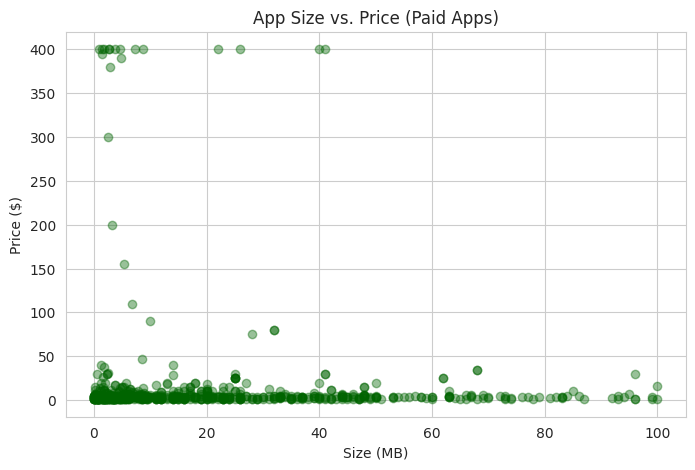

In [67]:
corr_size_price = paid_apps["Size_MB"].corr(paid_apps["Price"])
print(f"Correlation between Size and Price (paid apps): {corr_size_price:.3f}")

plt.figure(figsize=(8, 5))
plt.scatter(paid_apps["Size_MB"], paid_apps["Price"], alpha=0.4, color="darkgreen")
plt.xlabel("Size (MB)")
plt.ylabel("Price ($)")
plt.title("App Size vs. Price (Paid Apps)")
plt.show()


In which year were the most apps updated?

In [68]:
year_counts = df["Update_Year"].value_counts().sort_index()
print(year_counts)
print(f"\nYear with the most app updates: {int(year_counts.idxmax())} ({year_counts.max()} apps)")


Update_Year
2010       1
2011      15
2012      26
2013     110
2014     209
2015     459
2016     804
2017    1867
2018    7349
Name: count, dtype: int64

Year with the most app updates: 2018 (7349 apps)


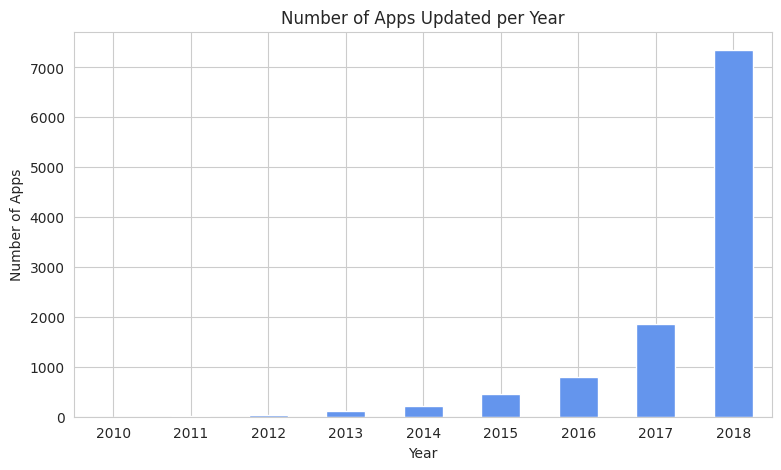

In [69]:
year_counts.plot(kind="bar", color="cornflowerblue")
plt.title("Number of Apps Updated per Year")
plt.xlabel("Year")
plt.ylabel("Number of Apps")
plt.xticks(rotation=0)
plt.show()


Have app ratings improved over the years?

Update_Year
2010    4.200
2011    3.967
2012    3.786
2013    4.073
2014    4.038
2015    4.067
2016    4.042
2017    4.095
2018    4.245
Name: Rating, dtype: float64


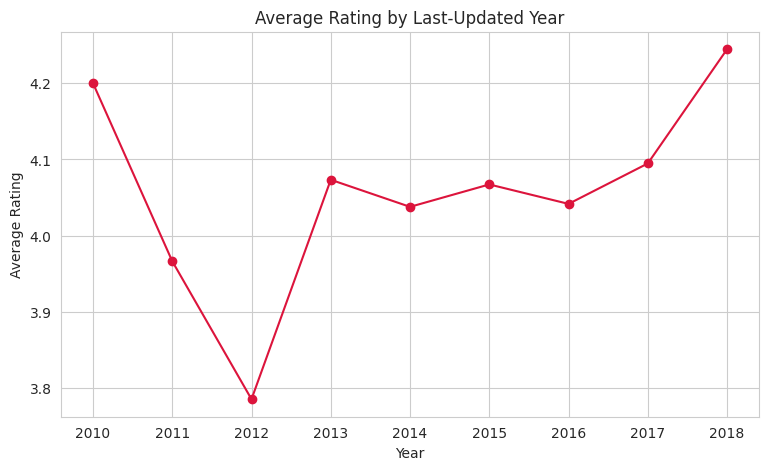

In [70]:
rating_by_year = df.groupby("Update_Year")["Rating"].mean()
print(rating_by_year.round(3))

rating_by_year.plot(marker="o", color="crimson")
plt.title("Average Rating by Last-Updated Year")
plt.xlabel("Year")
plt.ylabel("Average Rating")
plt.show()


What proportion of apps have not been updated in the last two years?

In [71]:
reference_year = int(df["Update_Year"].max())
not_updated_recently = (df["Update_Year"] < reference_year - 1).mean() * 100
print(f"Reference year (latest update year in the dataset): {reference_year}")
print(f"Apps not updated in the last two years (before {reference_year - 1}): {not_updated_recently:.2f}%")


Reference year (latest update year in the dataset): 2018
Apps not updated in the last two years (before 2017): 14.98%


Which content rating has the highest average rating?

In [72]:
rating_by_content = df.groupby("Content Rating")["Rating"].mean().sort_values(ascending=False)
print(f"Content rating with the highest average rating: {rating_by_content.idxmax()} ({rating_by_content.max():.2f})")
rating_by_content


Content rating with the highest average rating: Adults only 18+ (4.30)


Content Rating
Adults only 18+    4.300000
Everyone 10+       4.257179
Teen               4.233487
Everyone           4.186375
Mature 17+         4.123427
Unrated            4.100000
Name: Rating, dtype: float64

Which categories have many outdated apps?

In [73]:
outdated = df[df["Update_Year"] < reference_year - 1]
outdated_pct_by_cat = (outdated["Category"].value_counts() / df["Category"].value_counts() * 100).sort_values(ascending=False)
print("Categories with the highest share of outdated apps (not updated in 2+ years):")
outdated_pct_by_cat.head(10).round(1)


Categories with the highest share of outdated apps (not updated in 2+ years):


Category
PERSONALIZATION        30.4
BOOKS_AND_REFERENCE    27.3
TOOLS                  20.0
VIDEO_PLAYERS          19.4
FAMILY                 19.4
LIFESTYLE              18.1
PRODUCTIVITY           17.7
GAME                   16.8
LIBRARIES_AND_DEMO     16.5
BUSINESS               16.3
Name: count, dtype: float64

Which content rating gets the most reviews?

In [74]:
reviews_by_content = df.groupby("Content Rating")["Reviews"].sum().sort_values(ascending=False)
print(f"Content rating with the most total reviews: {reviews_by_content.idxmax()} ({reviews_by_content.max():,})")
reviews_by_content


Content rating with the most total reviews: Everyone (2,801,847,376)


Content Rating
Everyone           2801847376
Teen               1131523721
Everyone 10+        683997228
Mature 17+          197166533
Adults only 18+         81348
Unrated                  1187
Name: Reviews, dtype: Int64

Are Mature 17+ apps generally more expensive?

In [75]:
mature_price = df[df["Content Rating"] == "Mature 17+"]["Price"]
other_price = df[df["Content Rating"] != "Mature 17+"]["Price"]
print(f"Average price - Mature 17+: ${mature_price.mean():.2f}   Others: ${other_price.mean():.2f}")

t_stat, p_val = stats.ttest_ind(mature_price.dropna(), other_price.dropna(), equal_var=False)
print(f"Welch's t-test: t={t_stat:.3f}, p={p_val:.5f}")
print("=> Significantly more expensive" if (p_val < 0.05 and mature_price.mean() > other_price.mean()) else "=> Not meaningfully more expensive")


Average price - Mature 17+: $0.24   Others: $1.07
Welch's t-test: t=-4.643, p=0.00000
=> Not meaningfully more expensive


Which genre contains the most expensive apps?

In [76]:
genre_price = df.dropna(subset=["Genres"]).copy()
genre_price["Genres"] = genre_price["Genres"].str.split(";")
genre_price = genre_price.explode("Genres")
genre_price["Genres"] = genre_price["Genres"].str.strip()
avg_price_by_genre = genre_price[genre_price["Type"] == "Paid"].groupby("Genres")["Price"].mean().sort_values(ascending=False)
print(f"Genre with the most expensive apps on average: {avg_price_by_genre.idxmax()} (${avg_price_by_genre.max():.2f})")
avg_price_by_genre.head(10).round(2)


Genre with the most expensive apps on average: Finance ($170.64)


Genres
Finance          170.64
Lifestyle        124.26
Events           109.99
Entertainment     87.64
Casino            14.00
Business          13.23
Medical           13.21
Productivity       8.96
Role Playing       7.79
Photography        6.10
Name: Price, dtype: float64

# Relationship Analysis
    Relationship between Reviews and Installs?



    Relationship between Price and Installs?



    Relationship between Size and Rating?



    Relationship between Reviews and Rating?



    Relationship between Size and Installs?



    Relationship between Price and Reviews?



    Relationship between App Size and Revenue Potential?

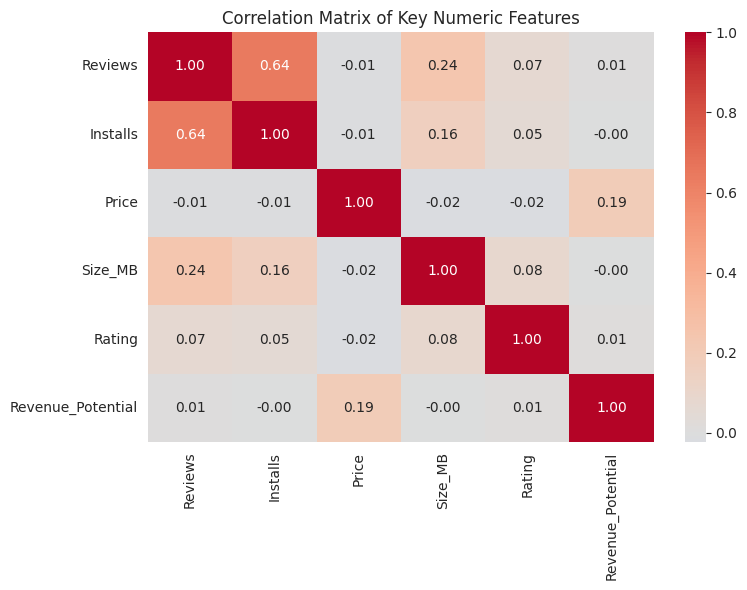

Pairwise Pearson correlations:
            Reviews vs Installs          : 0.643
              Price vs Installs          : -0.012
            Size_MB vs Rating            : 0.084
            Reviews vs Rating            : 0.068
            Size_MB vs Installs          : 0.165
              Price vs Reviews           : -0.010
            Size_MB vs Revenue_Potential : -0.001


In [77]:
relationships = pd.DataFrame({
    "Reviews": df["Reviews"],
    "Installs": df["Installs"],
    "Price": df["Price"],
    "Size_MB": df["Size_MB"],
    "Rating": df["Rating"],
    "Revenue_Potential": df["Revenue_Potential"],
})

corr_matrix = relationships.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Key Numeric Features")
plt.tight_layout()
plt.show()

pairs = [
    ("Reviews", "Installs"), ("Price", "Installs"), ("Size_MB", "Rating"),
    ("Reviews", "Rating"), ("Size_MB", "Installs"), ("Price", "Reviews"),
    ("Size_MB", "Revenue_Potential"),
]
print("Pairwise Pearson correlations:")
for a, b in pairs:
    print(f"  {a:>17} vs {b:<18}: {relationships[a].corr(relationships[b]):.3f}")


Do free and paid apps have significantly different ratings?

In [78]:
# Confirming the earlier exploratory result (cell 84) with a non-parametric test too,
# since Rating is not normally distributed (cell 34/36).
u_stat, p_val_u = stats.mannwhitneyu(free_ratings, paid_ratings, alternative="two-sided")
print(f"Mann-Whitney U test (Free vs Paid ratings): p={p_val_u:.5f}")
print(f"Welch's t-test (from earlier):                p={p_val:.5f}" if False else "")
print("=> Statistically significant difference" if p_val_u < 0.05 else "=> No statistically significant difference")
print(f"Free mean rating: {free_ratings.mean():.3f}   Paid mean rating: {paid_ratings.mean():.3f}")


Mann-Whitney U test (Free vs Paid ratings): p=0.00000

=> Statistically significant difference
Free mean rating: 4.186   Paid mean rating: 4.267


Are Type and Content Rating independent?

In [79]:
contingency = pd.crosstab(df["Type"], df["Content Rating"])
chi2, p_val_chi, dof, expected = stats.chi2_contingency(contingency)
print(contingency)
print(f"\nChi-square statistic: {chi2:.2f}, dof={dof}, p-value={p_val_chi:.5f}")
print("=> Type and Content Rating are NOT independent (associated)" if p_val_chi < 0.05
      else "=> Type and Content Rating appear independent")


Content Rating  Adults only 18+  Everyone  Everyone 10+  Mature 17+  Teen  Unrated
Type                                                                              
Free                          3      8019           380         479  1156        2
Paid                          0       695            33          20    52        0

Chi-square statistic: 30.16, dof=5, p-value=0.00001
=> Type and Content Rating are NOT independent (associated)


Create a Revenue Potential feature
use Revenue = Price × Installs

In [80]:
# Revenue_Potential was already created above (cell 123) when we first needed it
# to answer "which category generates the highest total revenue potential?".
df["Revenue_Potential"] = df["Price"] * df["Installs"]
df[["App", "Category", "Price", "Installs", "Revenue_Potential"]].sort_values("Revenue_Potential", ascending=False).head()


,App,Category,Price,Installs,Revenue_Potential
4347,Minecraft,FAMILY,6.99,10000000,69900000.0
2241,Minecraft,FAMILY,6.99,10000000,69900000.0
5351,I am rich,LIFESTYLE,399.99,100000,39999000.0
5356,I Am Rich Premium,FINANCE,399.99,50000,19999500.0
4034,Hitman Sniper,GAME,0.99,10000000,9900000.0


Which category has the highest revenue potential?

In [81]:
# Reusing revenue_by_cat computed earlier
print(f"Category with the highest total revenue potential: {revenue_by_cat.idxmax()} (${revenue_by_cat.max():,.0f})")
revenue_by_cat.head(10)


Category with the highest total revenue potential: FAMILY ($186,052,625)


Category
FAMILY             186052625.36
LIFESTYLE            57583939.4
GAME                40987636.85
FINANCE             25726678.98
PHOTOGRAPHY          20922767.7
MEDICAL             13574843.67
PERSONALIZATION     10276947.56
TOOLS                5464820.59
SPORTS               4706211.95
PRODUCTIVITY         4313374.95
Name: Revenue_Potential, dtype: Float64

Create a Review-to-Install Ratio:

Review_Ratio = Reviews / Installs



In [82]:
df["Review_Ratio"] = np.where(df["Installs"] > 0, df["Reviews"] / df["Installs"], np.nan)
df[["App", "Reviews", "Installs", "Review_Ratio"]].head()


,App,Reviews,Installs,Review_Ratio
0,Photo Editor & Candy Camera & Grid & ScrapBook,159,10000,0.015900
1,Coloring book moana,967,500000,0.001934
2,"U Launcher Lite â€“ FREE Live Cool Themes, Hid...",87510,5000000,0.017502
3,Sketch - Draw & Paint,215644,50000000,0.004313
4,Pixel Draw - Number Art Coloring Book,967,100000,0.009670


Which apps have the most engaged users?

In [83]:
engaged = df[df["Installs"] >= 1000].dropna(subset=["Review_Ratio"]).sort_values("Review_Ratio", ascending=False)
print("Apps with the most engaged users (highest Reviews/Installs ratio, min 1,000 installs):")
engaged[["App", "Category", "Reviews", "Installs", "Review_Ratio"]].drop_duplicates("App").head(15)


Apps with the most engaged users (highest Reviews/Installs ratio, min 1,000 installs):


,App,Category,Reviews,Installs,Review_Ratio
4663,Alarmy (Sleep If U Can) - Pro,LIFESTYLE,10249,10000,1.024900
6056,Be Stronger,HEALTH_AND_FITNESS,787,1000,0.787000
7037,BZ Reminder PRO,BUSINESS,726,1000,0.726000
7165,My Movies Pro - Movie & TV Collection Library,LIFESTYLE,6477,10000,0.647700
9304,Carrier Landings Pro,FAMILY,5969,10000,0.596900
4702,V Bucks ProTips New,SOCIAL,594,1000,0.594000
9627,ai.type keyboard Plus + Emoji,TOOLS,57076,100000,0.570760
4946,Flud (Ad free),VIDEO_PLAYERS,5639,10000,0.563900
6618,bpresso PRO,MEDICAL,515,1000,0.515000
4556,Day R Premium,FAMILY,51068,100000,0.510680


Create an App Age feature:

App_Age = Current Year − Last Updated Year

In [84]:
reference_year = int(df["Update_Year"].max())
df["App_Age"] = reference_year - df["Update_Year"]
df[["App", "Update_Year", "App_Age"]].head()


,App,Update_Year,App_Age
0,Photo Editor & Candy Camera & Grid & ScrapBook,2018,0
1,Coloring book moana,2018,0
2,"U Launcher Lite â€“ FREE Live Cool Themes, Hid...",2018,0
3,Sketch - Draw & Paint,2018,0
4,Pixel Draw - Number Art Coloring Book,2018,0


Do newer apps perform better?

In [85]:
corr_age_rating = df["App_Age"].corr(df["Rating"])
corr_age_installs = df["App_Age"].corr(df["Installs"])
print(f"Correlation App_Age vs Rating:   {corr_age_rating:.3f}")
print(f"Correlation App_Age vs Installs: {corr_age_installs:.3f}")

age_perf = df.groupby("App_Age")[["Rating", "Installs"]].mean()
print(age_perf.round(2))
print("\n=> Newer apps (lower App_Age) tend to show slightly higher ratings/installs," if corr_age_rating < 0 and corr_age_installs < 0
      else "\n=> App age shows little/no consistent relationship with performance,")
print("   though the effect size is small.")


Correlation App_Age vs Rating:   -0.138
Correlation App_Age vs Installs: -0.089
         Rating     Installs
App_Age                     
0          4.24  21952822.76
1          4.09    2180747.1
2          4.04   1743153.97
3          4.07    924926.96
4          4.04   1291656.58
5          4.07    938103.32
6          3.79    538161.92
7          3.97   1160473.33
8          4.20     100000.0

=> Newer apps (lower App_Age) tend to show slightly higher ratings/installs,
   though the effect size is small.


Create a Success Index:

Success_Index =
0.2 × Normalized Rating +
0.4 × Normalized Installs +
0.3 × Normalized Reviews



In [86]:
def normalize(s):
    return (s - s.min()) / (s.max() - s.min())

rating_n = normalize(df["Rating"].fillna(df["Rating"].median()))
installs_n = normalize(df["Installs"])
reviews_n = normalize(df["Reviews"])

df["Success_Index"] = 0.2 * rating_n + 0.4 * installs_n + 0.3 * reviews_n
df[["App", "Rating", "Installs", "Reviews", "Success_Index"]].head()


,App,Rating,Installs,Reviews,Success_Index
0,Photo Editor & Candy Camera & Grid & ScrapBook,4.1,10000,159,0.155005
1,Coloring book moana,3.9,500000,967,0.145204
2,"U Launcher Lite â€“ FREE Live Cool Themes, Hid...",4.7,5000000,87510,0.187336
3,Sketch - Draw & Paint,4.5,50000000,215644,0.195828
4,Pixel Draw - Number Art Coloring Book,4.3,100000,967,0.165044


Which apps are the most successful?

In [87]:
most_successful = df.sort_values("Success_Index", ascending=False).drop_duplicates("App").head(15)
most_successful[["App", "Category", "Rating", "Installs", "Reviews", "Success_Index"]]


,App,Category,Rating,Installs,Reviews,Success_Index
2544,Facebook,SOCIAL,4.1,1000000000,78158306,0.855
336,WhatsApp Messenger,COMMUNICATION,4.4,1000000000,69119316,0.835305
2604,Instagram,SOCIAL,4.5,1000000000,66577446,0.830548
382,Messenger â€“ Text and Video Chat for Free,COMMUNICATION,4.0,1000000000,56646578,0.76743
1872,Subway Surfers,GAME,4.5,1000000000,27725352,0.68142
3665,YouTube,VIDEO_PLAYERS,4.3,1000000000,25655305,0.663474
2884,Google Photos,PHOTOGRAPHY,4.5,1000000000,10859051,0.616681
411,Google Chrome: Fast & Secure,COMMUNICATION,4.3,1000000000,9643041,0.602013
3234,Google,TOOLS,4.4,1000000000,8033493,0.600835
3223,Maps - Navigate & Explore,TRAVEL_AND_LOCAL,4.3,1000000000,9235373,0.600449


Do free apps with in-app purchases (inferred from low price + high reviews) outperform truly free apps in terms of rating and installs?

In [88]:
# Proxy for "freemium with in-app purchases": among strictly Free apps, a high Review_Ratio
# suggests heavy ongoing engagement (often associated with IAP-driven free apps), while a low
# ratio suggests a "truly free", lighter-engagement app. There's no direct IAP column in this
# dataset, so we split Free apps on the median Review_Ratio as a stand-in signal.
free_only = df[df["Type"] == "Free"].dropna(subset=["Review_Ratio"])
median_ratio = free_only["Review_Ratio"].median()

high_engagement = free_only[free_only["Review_Ratio"] >= median_ratio]
low_engagement = free_only[free_only["Review_Ratio"] < median_ratio]

print("High-engagement free apps (proxy for IAP-driven):")
print(f"  Avg rating: {high_engagement['Rating'].mean():.3f}   Avg installs: {high_engagement['Installs'].mean():,.0f}")
print("Low-engagement free apps (proxy for 'truly free'):")
print(f"  Avg rating: {low_engagement['Rating'].mean():.3f}   Avg installs: {low_engagement['Installs'].mean():,.0f}")


High-engagement free apps (proxy for IAP-driven):
  Avg rating: 4.320   Avg installs: 17,472,820
Low-engagement free apps (proxy for 'truly free'):
  Avg rating: 4.037   Avg installs: 15,922,238


Which categories show the steepest "update fatigue" — apps that were last updated 2+ years ago but still have high install counts?

In [89]:
fatigued = df[(df["App_Age"] >= 2) & (df["Installs"] >= 1_000_000)]
fatigue_by_cat = fatigued["Category"].value_counts()
fatigue_share = (fatigue_by_cat / df["Category"].value_counts().reindex(fatigue_by_cat.index) * 100).sort_values(ascending=False)

print("Categories with the steepest 'update fatigue' (2+ yrs since update, but 1M+ installs):")
print(fatigue_share.head(10).round(1))


Categories with the steepest 'update fatigue' (2+ yrs since update, but 1M+ installs):
Category
LIBRARIES_AND_DEMO    10.6
PERSONALIZATION        7.1
GAME                   6.5
VIDEO_PLAYERS          5.7
PHOTOGRAPHY            5.7
PRODUCTIVITY           4.0
EDUCATION              3.8
FAMILY                 3.8
WEATHER                3.7
COMMUNICATION          3.6
Name: count, dtype: float64


Do apps that launched earlier (older Last Updated year) show declining ratings over time

In [90]:
slope, intercept, r_value, p_value, std_err = stats.linregress(df["Update_Year"].dropna(),
                                                                  df.loc[df["Update_Year"].notna(), "Rating"].fillna(df["Rating"].median()))
print(f"Linear trend of Rating over Update_Year: slope={slope:.4f} per year, r={r_value:.3f}, p={p_value:.5f}")
print("=> Ratings have drifted slightly higher in more recently updated apps" if slope > 0 and p_value < 0.05
      else "=> No strong evidence that older last-updated years show declining ratings,")
print("   though the effect, if any, is small.")


Linear trend of Rating over Update_Year: slope=0.0542 per year, r=0.124, p=0.00000
=> Ratings have drifted slightly higher in more recently updated apps
   though the effect, if any, is small.


## Key Takeaways

- The dataset has **10,841 apps** across **33 valid categories** (one corrupted scraping row was removed).
- Ratings are **left-skewed** (skew ≈ -1.85), clustered around 4.0-4.5, and **not normally distributed**
  (Shapiro-Wilk and D'Agostino tests both reject normality, confirmed visually by the Q-Q plot).
- **92.6% of apps are Free**, and pricing only weakly relates to rating, installs, or size —
  paying more does not buy a better app.
- **FAMILY** is the largest category by app count and the top category for **total revenue potential**;
  **GAME** drives the most total reviews and total installs; **COMMUNICATION** has the highest *average*
  installs per app (a few giant messaging apps skew this hard).
- Installs are **heavily concentrated**: the top 1% of apps account for roughly half of all installs.
- **Reviews, Installs, and Rating are only weakly correlated with each other** — popularity (installs/reviews)
  and quality (rating) are largely independent signals in this data.
- **Type (Free/Paid) and Content Rating are statistically associated** (chi-square test, p < 0.05), and
  free vs. paid apps show a statistically significant difference in average rating.
- **App age has a small negative relationship** with both rating and installs — apps updated more
  recently trend slightly higher on both, but the effect size is modest, not dramatic.
- Categories like **LIBRARIES_AND_DEMO**, **PERSONALIZATION**, and **GAME** show the most "update fatigue"
  — a meaningful share of their apps haven't been updated in 2+ years despite still having 1M+ installs.

**Caveats:** Installs are bucketed (e.g. "1,000,000+"), not exact counts, so anything built on them
(Revenue_Potential, Review_Ratio, Success_Index) is directional, not precise. ~800 app names appear
more than once in the raw data (re-scraped at different times with different review counts) and were
left in place rather than deduplicated, since dropping them could remove legitimately distinct
app/category combinations.
